<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
   EDA-Energy Consumption ⚡⚡ Data Analysis
</center></p></h1>

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">

  <!-- --------------------- INTRODUCTION -------------------- -->
  <h2 style="color:blue;"> Introduction</h2>
  <p style="text-align: justify; font-family: cursive; font-size: 14px; color: black;">
    The energy consumption dataset provides detailed insights into energy usage patterns
    across different building types, including <b>residential, commercial, and industrial</b>
    facilities. The dataset includes key features such as square footage, number of occupants,
    appliance usage, ambient temperature, and day-of-week effects.  
    This analysis is crucial for stakeholders focused on <b>energy efficiency, cost reduction,
    sustainability, and smart energy management</b>.
  </p>

  <hr>

  <!-- --------------------- GOALS -------------------- -->
  <h2 style="color:blue;"> Goals of the Analysis</h2>
  <p style="font-size:140%; color:#556b2f; font-family:Comic Sans MS; line-height:1.4;">
    • <b>Understand Energy Consumption Patterns</b> across building types under varying
    conditions such as temperature and occupancy.<br>
    • <b>Identify Key Influencing Factors</b> including square footage, number of occupants,
    appliance usage, and environmental variables.<br>
    • <b>Comparative Analysis</b> to evaluate differences between residential, commercial,
    and industrial buildings.<br>
    • <b>Forecast Future Energy Consumption</b> using historical data to support demand planning.<br>
    • <b>Support Sustainability Initiatives</b> by identifying opportunities for energy
    efficiency improvements.
  </p>

  <hr>



  <!-- --------------------- DATASET OVERVIEW -------------------- -->
  <h2 style="color:blue;"> Dataset Overview</h2>
  <p style="font-size:130%; color:#556b2f; font-family:Comic Sans MS; line-height:1.4;">
    **This dataset contains information about energy consumption, including:**
  </p>
  <ul style="font-size:130%; color:#556b2f; font-family:Comic Sans MS;">
    <li><b>Building Type:</b> Residential, Commercial, or Industrial.</li>
    <li><b>Square Footage:</b> Size of the building in square feet.</li>
    <li><b>Number of Occupants:</b> Number of people occupying the building.</li>
    <li><b>Appliances Used:</b> Number of appliances, reflecting potential energy load.</li>
    <li><b>Average Temperature:</b> Provides context for heating/cooling demand.</li>
    <li><b>Day of Week:</b> Weekday vs. weekend effect on energy consumption.</li>
    <li><b>Energy Consumption:</b> Total energy consumed (kWh) – primary target variable.</li>
  </ul>

  <hr>

  <!-- --------------------- FINAL SUMMARY -------------------- -->
  <p style="font-size:150%; color:red; font-family:Comic Sans MS; line-height:1.4;">
    In conclusion, combining machine learning models and time-series forecasting techniques
    enables accurate prediction of energy consumption across building types. These insights
    empower organizations to optimize energy usage, reduce costs, and support
    sustainability initiatives.
  </p>

</div>


In [1]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.subplots as sp
import plotly.graph_objects as go



import warnings 
warnings.filterwarnings('ignore')

https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption/data

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [2]:


train= pd.read_csv(r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series-Energy Consumption\Energy Consumption- Data Analysis\train_energy_data.csv')
test= pd.read_csv(r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series-Energy Consumption\Energy Consumption- Data Analysis\test_energy_data.csv')


In [3]:
train.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [4]:
test.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


In [5]:
df = pd.concat([train,test])

In [6]:
df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1100 non-null   object 
 1   Square Footage       1100 non-null   int64  
 2   Number of Occupants  1100 non-null   int64  
 3   Appliances Used      1100 non-null   int64  
 4   Average Temperature  1100 non-null   float64
 5   Day of Week          1100 non-null   object 
 6   Energy Consumption   1100 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 68.8+ KB


In [8]:
df.shape

(1100, 7)

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

## Handle missing values

In [9]:
# Check for missing values
df.isnull().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

# Duplicates


In [11]:
dupes=df.duplicated().sum()

print(dupes)

0


In [12]:
df.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,25500.527273,48.268182,25.730000,22.559745,4168.191273
std,14236.955632,29.127624,14.116209,7.122357,924.278723
min,560.000000,1.000000,1.000000,10.050000,1683.950000
25%,13203.750000,22.000000,13.000000,16.365000,3510.460000
50%,25785.500000,47.000000,26.000000,22.810000,4189.690000
75%,37536.750000,73.000000,38.000000,28.760000,4859.510000
max,49997.000000,99.000000,49.000000,34.990000,6530.600000


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Distribution and anlaysis data
</center></p></h1>

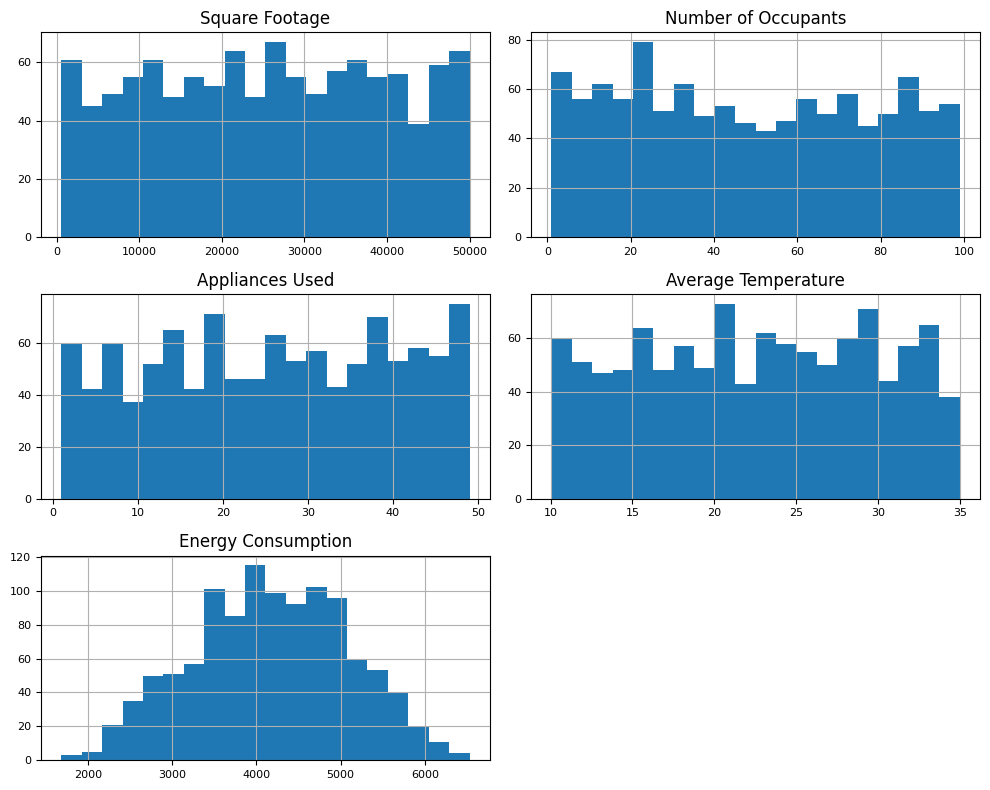

In [13]:
df.hist(figsize=(10, 8), bins=20, xlabelsize=8, ylabelsize=8)
plt.tight_layout()
plt.xlabel('Value', fontsize=10 , rotation=45)
plt.ylabel('Frequency', fontsize=10)
plt.show()

## Histogram for Energy Consumption

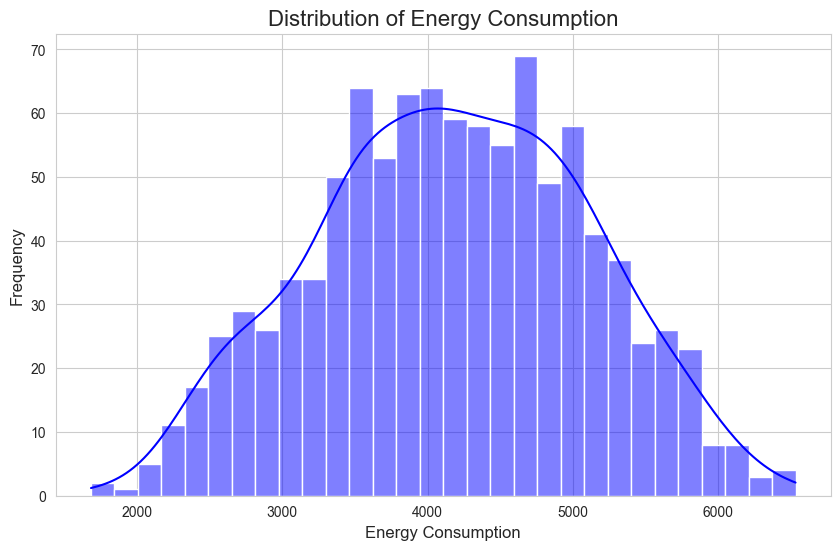

In [15]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(train['Energy Consumption'], kde=True, color='blue', bins=30)
plt.title('Distribution of Energy Consumption', fontsize=16)
plt.xlabel('Energy Consumption', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

## Average Energy Consumption by Building Type



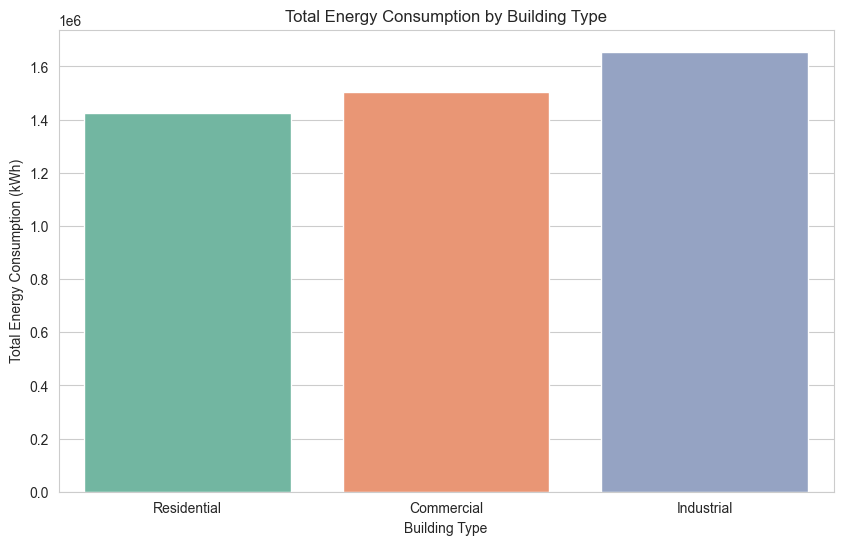

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Building Type', y='Energy Consumption', data=df, estimator=sum, ci=None , palette='Set2')
plt.title('Total Energy Consumption by Building Type')
plt.xlabel('Building Type')
plt.ylabel('Total Energy Consumption (kWh)')
plt.show()

## Average Energy Consumption by Day of Week

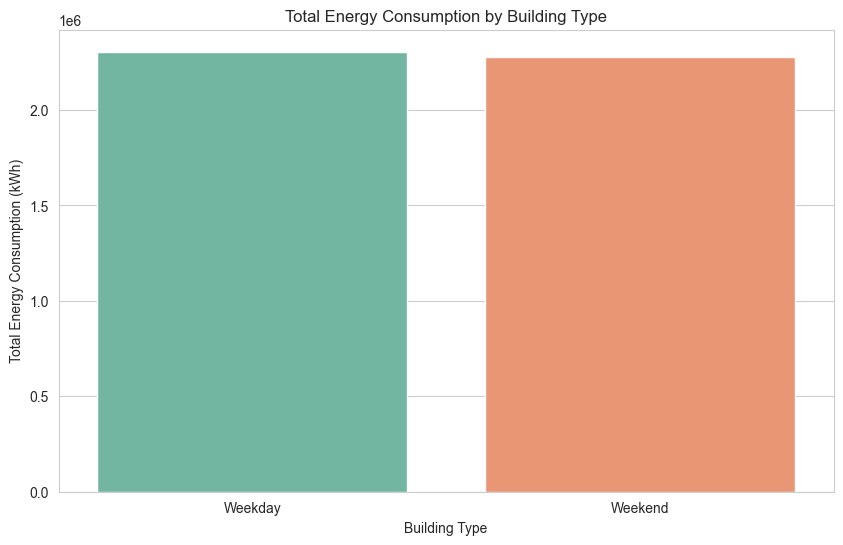

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Day of Week', y='Energy Consumption', data=df, estimator=sum, ci=None , palette='Set2')
plt.title('Total Energy Consumption by Building Type')
plt.xlabel('Building Type')
plt.ylabel('Total Energy Consumption (kWh)')
plt.show()

# Regression plot for Average Temperature vs Energy Consumption



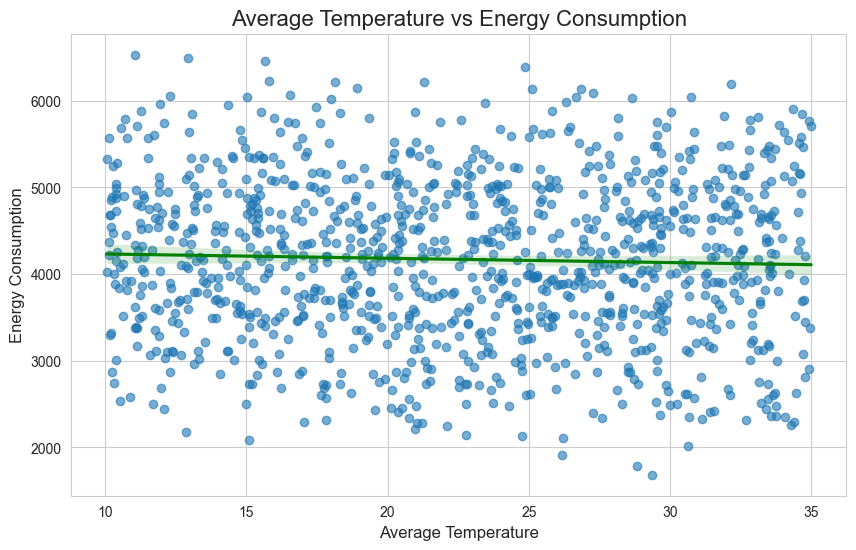

In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Average Temperature', y='Energy Consumption', scatter_kws={'alpha':0.6}, line_kws={'color':'green'})
plt.title('Average Temperature vs Energy Consumption', fontsize=16)
plt.xlabel('Average Temperature', fontsize=12)
plt.ylabel('Energy Consumption', fontsize=12)
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">

  <!-- --------------------- TEMPERATURE ANALYSIS -------------------- -->
  <h2 style="color:blue;"> Temperature vs. Energy Consumption Insights</h2>
  
  <p style="font-size:140%; color:#556b2f; font-family:Comic Sans MS; line-height:1.4;">
  <b>slight upward trend at lower temperatures</b> (below 15°C), suggesting a possible increase in energy consumption as temperatures drop. This is likely due to <b>increased heating needs</b>.<br><br>
    
  <b>higher temperatures</b> (above 25°C), the trend becomes slightly downward, which could be related to <b>cooling requirements or other factors<b>.<br><br>
    
  <b>significant amount of variability</b> in energy consumption for any given temperature, indicating that <b>other factors besides temperature</b>—such as occupancy, appliances, and building size—play a crucial role in determining energy usage.
  </p>

</div>



## Square Footage vs Energy Consumption


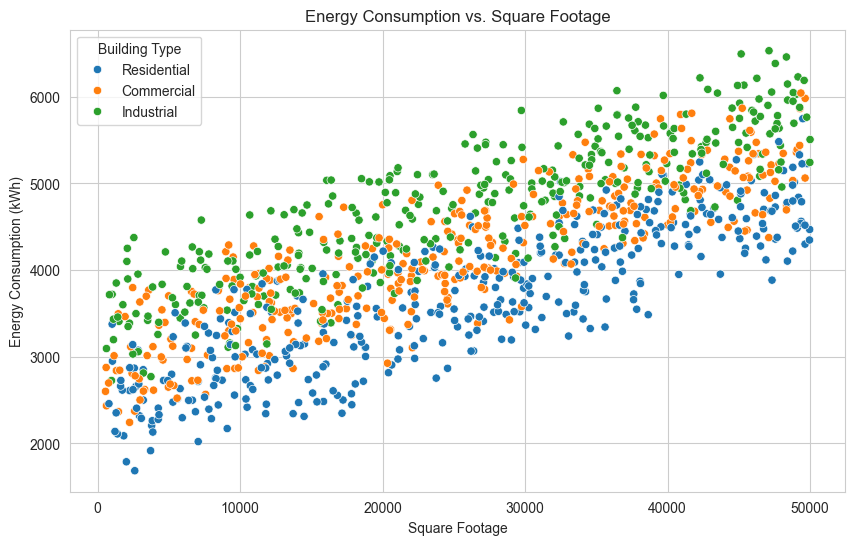

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Square Footage', y='Energy Consumption', hue='Building Type', data=df)
plt.title('Energy Consumption vs. Square Footage')
plt.xlabel('Square Footage')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

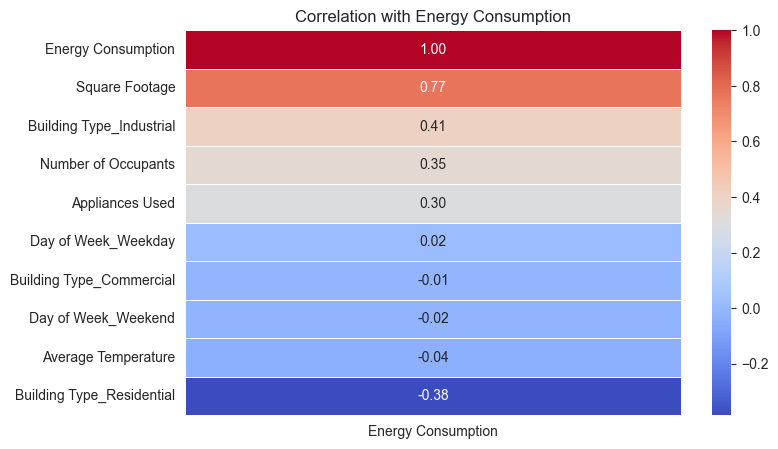

In [21]:
correlation_matrix = df.corr(numeric_only=True)
correlation_price = correlation_matrix['Energy Consumption'].sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_price.to_frame(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation with Energy Consumption')
plt.show()